# A/B test readout: robot task-allocation algorithm A vs B

**Decision to make.** Should the fleet switch from task-allocation algorithm **A** (control) to **B** (treatment)?

**Metrics, fixed before looking at results**
- *Primary:* task duration (minutes). Faster task completion is the goal.
- *Guardrails:* error rate (share of tasks with an error) and energy per task (kWh). B must not make these worse.
- *Decision rule:* ship B if duration improves significantly (α = 0.05, Holm-corrected across the three metrics)
  and neither guardrail gets significantly worse.

**Data.** 5,000 simulated task logs (100 robots, three task types, January–February 2025). The original pipeline ran on AWS
(S3 → Glue → Athena → SageMaker → QuickSight). This notebook reproduces the analysis locally, using DuckDB in place of Athena.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, duckdb, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, confint_proportions_2indep

sns.set_theme(style="whitegrid"); pd.set_option("display.precision", 4)
rng = np.random.default_rng(7)
df = pd.read_csv("robotic_task_logs.csv", parse_dates=["start_time", "end_time"])
A, B = df[df.algorithm == "A"], df[df.algorithm == "B"]
print(df.shape, df.start_time.min().date(), "to", df.start_time.max().date())

(5000, 8) 2025-01-01 to 2025-03-11


## 1. Per-arm summary (the same SQL runs in Athena)

In [2]:
con = duckdb.connect(); con.register("robotic_task_logs", df)
display(con.execute(open("sql/arm_summary.sql").read()).df())

,algorithm,tasks,avg_duration_min,sd_duration_min,error_rate,avg_energy_kwh,sd_energy_kwh
0,A,2510,29.8134,5.0804,0.0530,11.9900,1.9871
1,B,2490,28.0917,4.5396,0.0301,11.2022,2.0270


## 2. Sanity checks before reading any result
**Sample ratio mismatch (SRM):** if the intended split was 50/50, is the observed split plausible?
**Balance:** are task types and robots spread evenly across arms? If B got more of the easy tasks, a duration difference would be misleading.

In [3]:
counts = df.algorithm.value_counts().sort_index()
srm_p = stats.chisquare(counts.values).pvalue
print(f"allocation A={counts['A']}, B={counts['B']}  SRM chi-square p = {srm_p:.3f}", "(OK)" if srm_p > 0.01 else "(SRM! investigate)")
mix = pd.crosstab(df.task_type, df.algorithm, normalize="columns")
print("task-type balance chi-square p =", round(stats.chi2_contingency(pd.crosstab(df.task_type, df.algorithm))[1], 3))
display(mix)
per_robot = pd.crosstab(df.robot_id, df.algorithm)
print("robots that ran both algorithms:", int(((per_robot > 0).sum(axis=1) == 2).sum()), "of", len(per_robot))

allocation A=2510, B=2490  SRM chi-square p = 0.777 (OK)
task-type balance chi-square p = 0.816


algorithm,A,B
task_type,,
move,0.3303,0.3245
pick,0.3231,0.3313
place,0.3466,0.3442


robots that ran both algorithms: 100 of 100


## 3. Effect sizes with confidence intervals
A p-value only says the difference is unlikely to be zero. The decision needs **how big** the difference is and how sure we are.

In [4]:
def welch_diff(a, b):
    d = b.mean() - a.mean(); se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    dof = se**4 / ((a.var(ddof=1) / len(a))**2 / (len(a) - 1) + (b.var(ddof=1) / len(b))**2 / (len(b) - 1))
    t = stats.t.ppf(0.975, dof); p = stats.ttest_ind(b, a, equal_var=False).pvalue
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return {"A": a.mean(), "B": b.mean(), "diff (B-A)": d, "CI low": d - t * se, "CI high": d + t * se,
            "relative change": d / a.mean(), "effect size (Cohen's d)": d / pooled, "p": p}

def prop_diff(a, b):
    ca, cb, na, nb = a.sum(), b.sum(), len(a), len(b)
    lo, hi = confint_proportions_2indep(cb, nb, ca, na, method="newcomb")
    p = stats.chi2_contingency([[ca, na - ca], [cb, nb - cb]])[1]
    return {"A": ca / na, "B": cb / nb, "diff (B-A)": cb / nb - ca / na, "CI low": lo, "CI high": hi,
            "relative change": (cb / nb - ca / na) / (ca / na), "effect size (Cohen's d)": np.nan, "p": p}

res = pd.DataFrame({
    "duration_min (primary)": welch_diff(A.duration_min, B.duration_min),
    "error_rate (guardrail)": prop_diff(A.error_occurred, B.error_occurred),
    "energy_kwh (guardrail)": welch_diff(A.energy_kwh, B.energy_kwh),
}).T
res["p (Holm-adjusted)"] = multipletests(res.p.astype(float), method="holm")[1]
display(res)

,A,B,diff (B-A),CI low,CI high,relative change,effect size (Cohen's d),p,p (Holm-adjusted)
duration_min (primary),29.8134,28.0917,-1.7217,-1.9888,-1.4546,-0.0577,-0.3574,4.6841e-36,9.3683e-36
error_rate (guardrail),0.0530,0.0301,-0.0229,-0.0341,-0.0118,-0.4316,NaN,6.9437e-05,6.9437e-05
energy_kwh (guardrail),11.9900,11.2022,-0.7878,-0.8991,-0.6765,-0.0657,-0.3925,5.4785e-43,1.6435e-42


Bootstrap check on the primary metric (no normality assumption): resample tasks within each arm 5,000 times.

In [5]:
boot = np.array([rng.choice(B.duration_min.values, len(B)).mean() - rng.choice(A.duration_min.values, len(A)).mean() for _ in range(5000)])
print(f"bootstrap 95% CI for duration difference: [{np.percentile(boot, 2.5):.3f}, {np.percentile(boot, 97.5):.3f}] minutes")

bootstrap 95% CI for duration difference: [-1.990, -1.459] minutes


## 4. Was the test big enough?
Minimum detectable effect (MDE) at 80% power and α = 0.05 for this sample size, compared with the effect actually observed.

In [6]:
nA, nB = len(A), len(B)
mde_d = TTestIndPower().solve_power(nobs1=nA, ratio=nB / nA, alpha=0.05, power=0.8)
mde_dur = mde_d * np.sqrt((A.duration_min.var() + B.duration_min.var()) / 2)
mde_h = NormalIndPower().solve_power(nobs1=nA, ratio=nB / nA, alpha=0.05, power=0.8)
base = A.error_occurred.mean()
# smallest drop in error rate detectable: solve Cohen's h = mde_h for p_B below base
p_grid = np.linspace(0.0005, base, 2000); mde_err = base - p_grid[np.argmin(np.abs(np.abs(proportion_effectsize(p_grid, base)) - mde_h))]
print(f"duration: MDE ≈ {mde_dur:.2f} min vs observed {abs(res.loc['duration_min (primary)', 'diff (B-A)']):.2f} min")
print(f"error rate: MDE ≈ {mde_err*100:.2f} pp vs observed {abs(res.loc['error_rate (guardrail)', 'diff (B-A)'])*100:.2f} pp")

duration: MDE ≈ 0.38 min vs observed 1.72 min
error rate: MDE ≈ 1.63 pp vs observed 2.29 pp


## 5. Is the effect consistent across task types?
Regression adjusts for task type and checks whether B helps every kind of task (robust standard errors).

In [7]:
ols = smf.ols("duration_min ~ C(algorithm, Treatment('A')) + C(task_type)", data=df).fit(cov_type="HC3")
print(f"adjusted B effect on duration: {ols.params.iloc[1]:.3f} min (95% CI {ols.conf_int().iloc[1,0]:.3f} to {ols.conf_int().iloc[1,1]:.3f})")
by_type = df.groupby(["task_type", "algorithm"]).duration_min.mean().unstack()
by_type["diff (B-A)"] = by_type.B - by_type.A
display(by_type)

adjusted B effect on duration: -1.719 min (95% CI -1.986 to -1.452)


algorithm,A,B,diff (B-A)
task_type,,,
move,30.1022,28.0763,-2.0259
pick,29.6399,27.9109,-1.7289
place,29.7001,28.2804,-1.4198


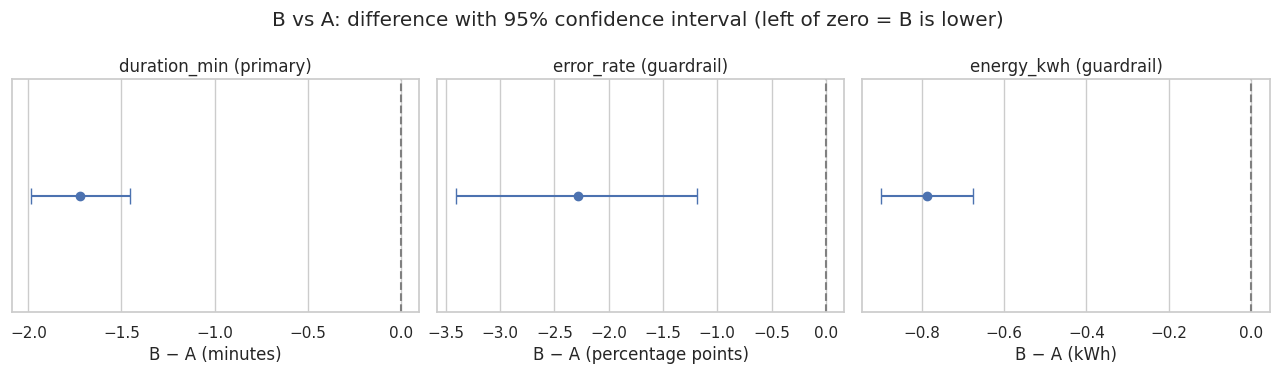

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (lab, row) in zip(axes, res.iterrows()):
    scale = 100 if "error" in lab else 1
    ax.errorbar([row["diff (B-A)"] * scale], [0], xerr=[[(row["diff (B-A)"] - row["CI low"]) * scale], [(row["CI high"] - row["diff (B-A)"]) * scale]],
                fmt="o", color="#4C72B0", capsize=6)
    ax.axvline(0, color="grey", ls="--"); ax.set_yticks([]); ax.set_title(lab)
    ax.set_xlabel("B − A" + (" (percentage points)" if "error" in lab else (" (minutes)" if "duration" in lab else " (kWh)")))
plt.suptitle("B vs A: difference with 95% confidence interval (left of zero = B is lower)")
plt.tight_layout(); plt.savefig("images/effects_ci.png", dpi=120); plt.show()

## 6. What it means operationally

In [9]:
per_1000 = pd.Series({
    "robot-minutes saved per 1,000 tasks": -res.loc["duration_min (primary)", "diff (B-A)"] * 1000,
    "errors avoided per 1,000 tasks": -res.loc["error_rate (guardrail)", "diff (B-A)"] * 1000,
    "kWh saved per 1,000 tasks": -res.loc["energy_kwh (guardrail)", "diff (B-A)"] * 1000,
})
display(per_1000.round(1).to_frame("B vs A"))

,B vs A
"robot-minutes saved per 1,000 tasks",1721.7
"errors avoided per 1,000 tasks",22.9
"kWh saved per 1,000 tasks",787.8


## 7. Decision

**Ship algorithm B.**
- *Primary metric:* B cuts task duration by **1.72 minutes (−5.8%)**, 95% CI −1.99 to −1.45. That's 4.5× the smallest effect this test
  could reliably detect (0.38 min), and it holds after adjusting for task type and across all three task types (−1.4 to −2.0 min).
- *Guardrails:* both improve rather than degrade. Error rate falls from 5.3% to 3.0% (−2.3 pp, CI −3.4 to −1.2) and energy falls by 0.79 kWh per task (−6.6%).
  All three results stay significant after Holm correction.
- *Checks passed:* no sample ratio mismatch (p = 0.78), task types balanced across arms, all 100 robots ran both algorithms.

**Caveats.** The logs are simulated, so the effect sizes illustrate the method rather than a real fleet. The error-rate test
could only reliably detect drops of about 1.6 pp or more, and the observed 2.3 pp sits close to that limit, so it's worth
monitoring after rollout. A real rollout would also watch for novelty effects over time and robot-level clustering.